ARIMA Modeling for Apple Stock Prediction

To build an ARIMA model to predict future stock returns for Apple and evaluate its performance in capturing market dynamics.

Import Libraries

The required Python libraries were imported to handle data processing, visualization, model building, and evaluation of prediction performance.

In [208]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error

import warnings
warnings.filterwarnings("ignore")

Data Loading and Preparation

The stock dataset was loaded and the date column was converted into a datetime format and set as the index to ensure proper time-series ordering.

In [209]:
df = pd.read_csv("../../data/Apple.csv")

df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

df = df.sort_index()

print(df.head())

             Open   High    Low  Close  Adj Close       Volume
Date                                                          
2015-01-02  27.85  27.86  26.84  27.33      24.21  212,818,400
2015-01-05  27.07  27.16  26.35  26.56      23.53  257,142,000
2015-01-06  26.64  26.86  26.16  26.57      23.53  263,188,400
2015-01-07  26.80  27.05  26.67  26.94      23.86  160,423,600
2015-01-08  27.31  28.04  27.17  27.97      24.78  237,458,000


Convert to Weekly Data

The daily stock data was resampled into weekly frequency using Friday closing prices to reduce noise and capture more stable trends.

In [210]:
df = df.resample('W-FRI').last() 
 
df['Return'] = df['Close'].pct_change() 
df = df.dropna()

Feature Engineering

Additional features such as lagged returns, moving averages, and volatility were created to help the model capture temporal patterns and market behavior more effectively.


In [211]:
df['lag1'] = df['Return'].shift(1) 
df['lag2'] = df['Return'].shift(2) 
 
# Moving averages 
df['ma4'] = df['Return'].rolling(4).mean() 
df['ma8'] = df['Return'].rolling(8).mean() 
 
# Volatility 
df['volatility'] = df['Return'].rolling(4).std() 
 
df = df.dropna() 


Create Target Variables 

Future return targets were defined for both short-term (1-week ahead) and medium-term (4-week ahead) forecasting to align with the project’s prediction goals. 

In [212]:
# 1-week ahead return 
df['target_1w'] = df['Return'].shift(-1) 
 
# 4-week ahead return 
df['target_4w'] = df['Return'].rolling(4).sum().shift(-4) 
 
df = df.dropna()

Train/Validation/Test Split 

The dataset was split into training, validation, and test sets based on time to simulate real-world forecasting and prevent data leakage. 

In [213]:
train = df[(df.index >= "2022-01-01") & (df.index < "2024-01-01")]
val = df[(df.index >= "2024-01-01") & (df.index < "2025-01-01")]
test_aapl = df[df.index >= "2025-01-01"]

print("Train size:", len(train))
print("Val size:", len(val))
print("Test size:", len(test)) 

Train size: 104
Val size: 52
Test size: 57


Feature Selection 

Relevant features such as lag values, moving averages, and volatility were selected as inputs to improve model performance. 

In [214]:
features = ['lag1', 'lag2', 'ma4', 'ma8', 'volatility']

Walk-Forward ARIMAX Model 

A walk-forward validation approach was implemented to train the ARIMAX model sequentially, ensuring realistic predictions by updating the model with new data at each step.

In [215]:
def walk_forward_arimax(train, test, features): 
     
    history_y = list(train['Return']) 
    history_x = train[features].copy() 
     
    predictions = [] 
 
    for i in range(len(test)): 
         
        model = SARIMAX( 
            history_y, 
            exog=history_x, 
            order=(1,1,1), 
            enforce_stationarity=False, 
            enforce_invertibility=False 
        ) 
         
        model_fit = model.fit(disp=False) 
         
        exog_test = test[features].iloc[i:i+1] 
         
        yhat = model_fit.forecast(steps=1, exog=exog_test).iloc[0]
        predictions.append(yhat) 
         
        # update history 
        history_y.append(test['Return'].iloc[i]) 
        history_x = pd.concat([history_x, exog_test]) 
     
    return pd.Series(predictions, index=test.index)



Train and Predict 

The ARIMAX model was trained on historical data and used to generate predictions for future stock returns. 

In [216]:
predictions = walk_forward_arimax(train, test, features)
print(predictions.head())

Date
2025-01-03   -0.011888
2025-01-10   -0.013348
2025-01-17    0.008975
2025-01-24    0.039904
2025-01-31   -0.097315
Freq: W-FRI, dtype: float64


In [217]:
pred_aapl = walk_forward_arimax(train, test, features)

Model Evaluation 

The model performance was evaluated using MAE, RMSE, and directional accuracy to measure prediction error and correctness of movement direction. 

In [218]:
mae = mean_absolute_error(test['Return'], predictions) 
rmse = np.sqrt(mean_squared_error(test['Return'], predictions)) 
 
direction = np.mean(np.sign(predictions) == np.sign(test['Return'])) 
 
print("MAE:", mae) 
print("RMSE:", rmse) 
print("Directional Accuracy:", direction) 


MAE: 0.03193837555458887
RMSE: 0.041596170460136125
Directional Accuracy: 0.7894736842105263


Plot Actual vs Predicted

Actual and predicted returns were plotted to visually assess how well the model captures trends and fluctuations in the data. 

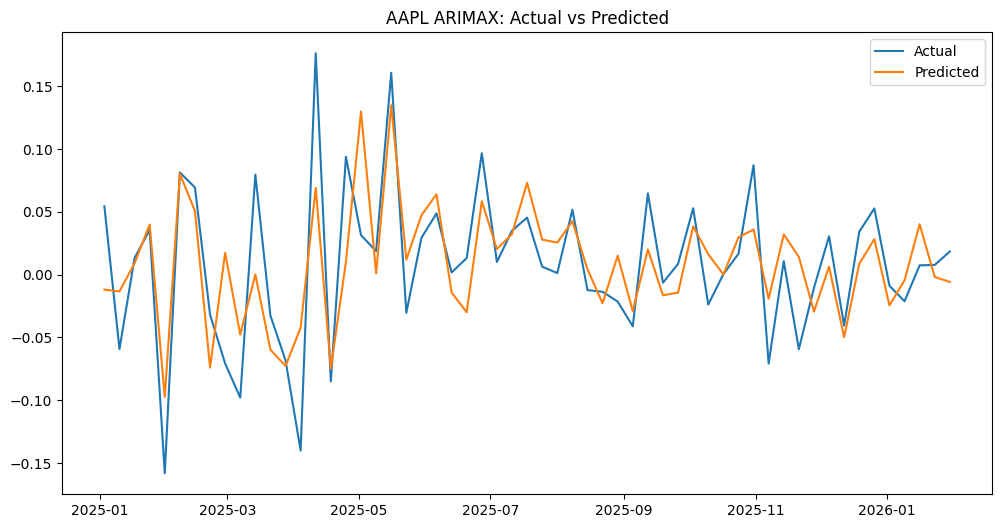

In [219]:
plt.figure(figsize=(12,6)) 
plt.plot(test['Return'], label='Actual') 
plt.plot(predictions, label='Predicted') 
plt.legend() 
plt.title("AAPL ARIMAX: Actual vs Predicted") 
plt.show() 

Trading Strategy 

Buy and sell signals were generated based on predicted returns to convert model outputs into actionable investment decisions. 

In [220]:
signals = np.where(predictions > 0, "BUY", "SELL") 
 
strategy_returns = [] 
 
for i in range(len(test)): 
    if signals[i] == "BUY": 
        strategy_returns.append(test['Return'].iloc[i]) 
    else: 
        strategy_returns.append(-test['Return'].iloc[i]) 
 
strategy_returns = pd.Series(strategy_returns, index=test.index) 

Backtesting 

A backtesting framework was implemented to simulate portfolio performance over time and compare the strategy against a buy-and-hold approach. 

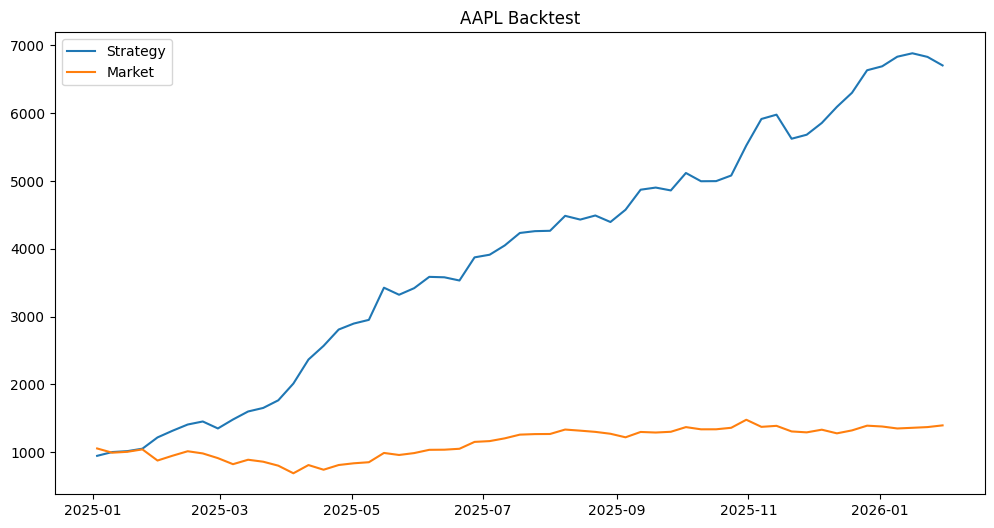

In [221]:
initial = 1000 
 
strategy_cum = (1 + strategy_returns).cumprod() * initial 
market_cum = (1 + test['Return']).cumprod() * initial 
 
plt.figure(figsize=(12,6)) 
plt.plot(strategy_cum, label="Strategy") 
plt.plot(market_cum, label="Market") 
plt.legend() 
plt.title("AAPL Backtest") 
plt.show() 

 

AMAZON STOCK PREDICTION

Data Loading and Preparation

In [222]:
df = pd.read_csv("../../data/Amazon.csv")

df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

df = df.sort_index()

print(df.head())

             Open   High    Low  Close   Adj Close       Volume
Date                                                           
2015-01-02  15.63  15.74  15.35   15.43       15.43  55,664,000
2015-01-05  15.35  15.42  15.04   15.11       15.11  55,484,000
2015-01-06  15.11  15.15  14.62   14.76       14.76  70,380,000
2015-01-07  14.88  15.06  14.77   14.92       14.92  52,806,000
2015-01-08  15.02  15.16  14.81   15.02       15.02  61,768,000


Convert to Weekly Data

The daily stock data was resampled into weekly frequency using Friday closing prices to reduce noise and capture more stable trends.

In [223]:
df = df.resample('W-FRI').last()

# Debug: check what columns actually exist after resample
print(df.columns.tolist())

# Strip whitespace from column names (common culprit)
df.columns = df.columns.str.strip()

df['Return'] = df['Close'].pct_change()
df = df.dropna()

['Open', 'High', 'Low', 'Close\xa0', 'Adj Close\xa0', 'Volume']


Feature Engineering

In [224]:
# Lag features 
df['lag1'] = df['Return'].shift(1) 
df['lag2'] = df['Return'].shift(2) 
 
# Moving averages 
df['ma4'] = df['Return'].rolling(4).mean() 
df['ma8'] = df['Return'].rolling(8).mean() 
 
# Volatility 
df['volatility'] = df['Return'].rolling(4).std() 
 
df = df.dropna() 


Target

In [225]:
# 1-week ahead return 
df['target_1w'] = df['Return'].shift(-1) 
 
# 4-week ahead return 
df['target_4w'] = df['Return'].rolling(4).sum().shift(-4) 
 
df = df.dropna() 


Train / Val / Test Split 

In [226]:
train = df[(df.index >= "2022-01-01") & (df.index < "2024-01-01")]
val = df[(df.index >= "2024-01-01") & (df.index < "2025-01-01")]
test_amzn = df[df.index >= "2025-01-01"]

print("Train size:", len(train))
print("Val size:", len(val))
print("Test size:", len(test)) 

Train size: 104
Val size: 52
Test size: 57


Select Features 

In [227]:
features = ['lag1', 'lag2', 'ma4', 'ma8', 'volatility'] 


Walk-Forward ARIMAX 

In [228]:
def walk_forward_arimax(train, test, features): 
     
    history_y = list(train['Return']) 
    history_x = train[features].copy() 
     
    predictions = [] 
 
    for i in range(len(test)): 
         
        model = SARIMAX( 
            history_y, 
            exog=history_x, 
            order=(1,1,1), 
            enforce_stationarity=False, 
            enforce_invertibility=False 
        ) 
         
        model_fit = model.fit(disp=False) 
         
        exog_test = test[features].iloc[i:i+1] 
         
        yhat = model_fit.forecast(steps=1, exog=exog_test).iloc[0]
        predictions.append(yhat) 
         
        # update history 
        history_y.append(test['Return'].iloc[i]) 
        history_x = pd.concat([history_x, exog_test]) 
     
    return pd.Series(predictions, index=test.index)



Train Model & Predict

In [229]:
predictions = walk_forward_arimax(train, test, features)
print(predictions.head())

Date
2025-01-03   -0.008833
2025-01-10   -0.008844
2025-01-17    0.015034
2025-01-24    0.041344
2025-01-31   -0.089160
Freq: W-FRI, dtype: float64


In [230]:
pred_amzn = walk_forward_arimax(train, test, features)

Evaluate Model

In [231]:
mae = mean_absolute_error(test['Return'], predictions) 
rmse = np.sqrt(mean_squared_error(test['Return'], predictions)) 
 
direction = np.mean(np.sign(predictions) == np.sign(test['Return'])) 
 
print("MAE:", mae) 
print("RMSE:", rmse) 
print("Directional Accuracy:", direction) 


MAE: 0.032293783980993834
RMSE: 0.043460894220391975
Directional Accuracy: 0.8070175438596491


Plot Actual vs Predicted

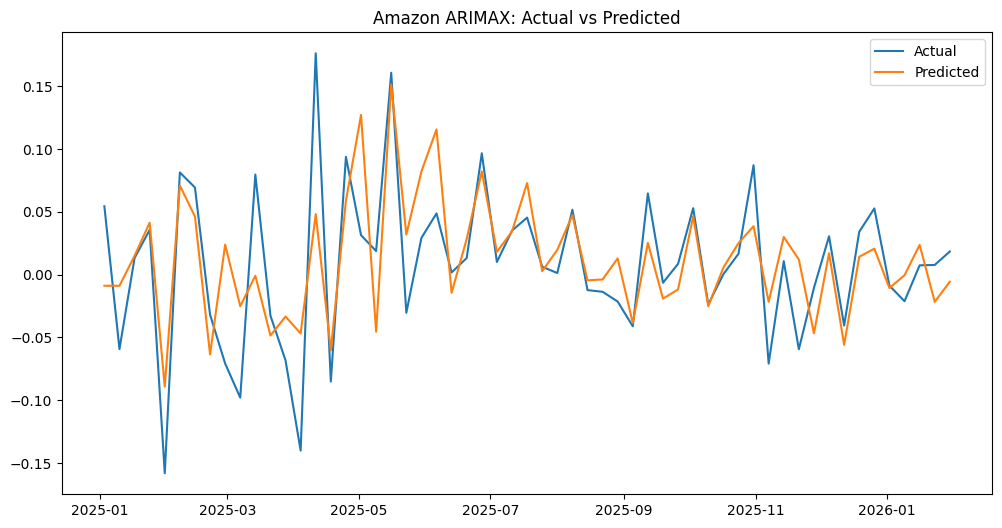

In [232]:
plt.figure(figsize=(12,6)) 
plt.plot(test['Return'], label='Actual') 
plt.plot(predictions, label='Predicted') 
plt.legend() 
plt.title("Amazon ARIMAX: Actual vs Predicted") 
plt.show() 

Strategy Returns

In [233]:
signals = np.where(predictions > 0, "BUY", "SELL") 
 
strategy_returns = [] 
 
for i in range(len(test)): 
    if signals[i] == "BUY": 
        strategy_returns.append(test['Return'].iloc[i]) 
    else: 
        strategy_returns.append(-test['Return'].iloc[i]) 
 
strategy_returns = pd.Series(strategy_returns, index=test.index) 

Plot Backtesting

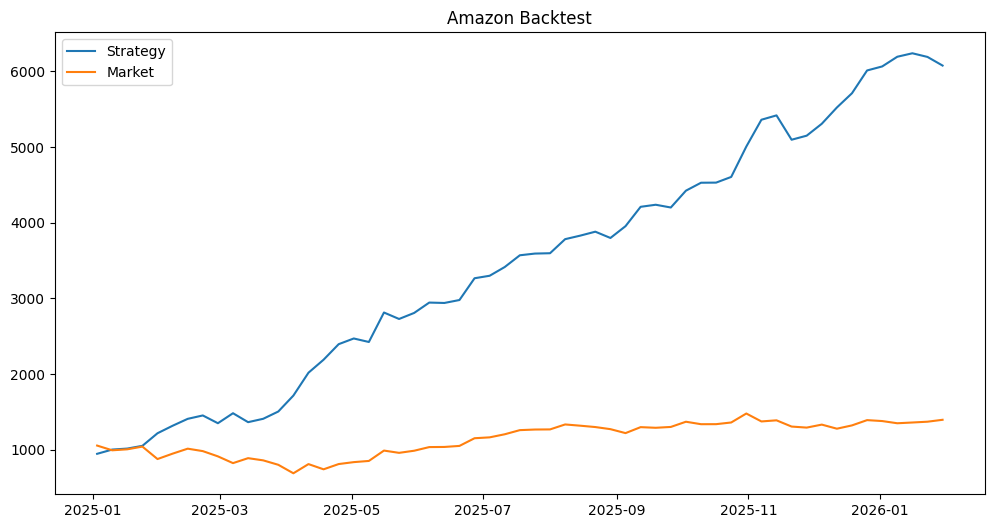

In [234]:
initial = 1000 
 
strategy_cum = (1 + strategy_returns).cumprod() * initial 
market_cum = (1 + test['Return']).cumprod() * initial 
 
plt.figure(figsize=(12,6)) 
plt.plot(strategy_cum, label="Strategy") 
plt.plot(market_cum, label="Market") 
plt.legend() 
plt.title("Amazon Backtest") 
plt.show() 

GOOGLE STOCK PREDICTION

Data Loading and Preparation

In [235]:
df = pd.read_csv("../../data/google.csv")

df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

df = df.sort_index()

print(df.head())

             Open   High    Low  Close   Adj Close       Volume
Date                                                           
2015-01-02  26.63  26.79  26.39   26.48       26.28  26,480,000
2015-01-05  26.36  26.40  25.89   25.97       25.78  41,182,000
2015-01-06  26.02  26.06  25.28   25.33       25.14  54,456,000
2015-01-07  25.55  25.57  25.18   25.26       25.07  46,918,000
2015-01-08  25.08  25.38  24.75   25.35       25.16  73,054,000


Convert to Weekly Data

The daily stock data was resampled into weekly frequency using Friday closing prices to reduce noise and capture more stable trends.

In [236]:
df = df.resample('W-FRI').last()

# Debug: check what columns actually exist after resample
print(df.columns.tolist())

# Strip whitespace from column names (common culprit)
df.columns = df.columns.str.strip()

df['Return'] = df['Close'].pct_change()
df = df.dropna()

['Open', 'High', 'Low', 'Close\xa0', 'Adj Close\xa0', 'Volume']


Feature Engineering

In [237]:
# Lag features 
df['lag1'] = df['Return'].shift(1) 
df['lag2'] = df['Return'].shift(2) 
 
# Moving averages 
df['ma4'] = df['Return'].rolling(4).mean() 
df['ma8'] = df['Return'].rolling(8).mean() 
 
# Volatility 
df['volatility'] = df['Return'].rolling(4).std() 
 
df = df.dropna()

Target

In [238]:
# 1-week ahead return 
df['target_1w'] = df['Return'].shift(-1) 
 
# 4-week ahead return 
df['target_4w'] = df['Return'].rolling(4).sum().shift(-4) 
 
df = df.dropna() 


Train / Val / Test Split 

In [239]:
train = df[(df.index >= "2022-01-01") & (df.index < "2024-01-01")]
val = df[(df.index >= "2024-01-01") & (df.index < "2025-01-01")]
test_googl = df[df.index >= "2025-01-01"]

print("Train size:", len(train))
print("Val size:", len(val))
print("Test size:", len(test)) 

Train size: 104
Val size: 52
Test size: 57


Select Features

In [240]:
features = ['lag1', 'lag2', 'ma4', 'ma8', 'volatility'] 


Walk Forward ArimaX

In [241]:
def walk_forward_arimax(train, test, features): 
     
    history_y = list(train['Return']) 
    history_x = train[features].copy() 
     
    predictions = [] 
 
    for i in range(len(test)): 
         
        model = SARIMAX( 
            history_y, 
            exog=history_x, 
            order=(1,1,1), 
            enforce_stationarity=False, 
            enforce_invertibility=False 
        ) 
         
        model_fit = model.fit(disp=False) 
         
        exog_test = test[features].iloc[i:i+1] 
         
        yhat = model_fit.forecast(steps=1, exog=exog_test).iloc[0]
        predictions.append(yhat) 
         
        # update history 
        history_y.append(test['Return'].iloc[i]) 
        history_x = pd.concat([history_x, exog_test]) 
     
    return pd.Series(predictions, index=test.index)



Train Model & Predict

In [242]:
predictions = walk_forward_arimax(train, test, features) 
print(predictions.head())

Date
2025-01-03   -0.017974
2025-01-10   -0.011797
2025-01-17    0.024361
2025-01-24    0.031200
2025-01-31   -0.125678
Freq: W-FRI, dtype: float64


In [243]:
pred_googl = walk_forward_arimax(train, test, features)

Evaluate Model

In [244]:
mae = mean_absolute_error(test['Return'], predictions) 
rmse = np.sqrt(mean_squared_error(test['Return'], predictions)) 
 
direction = np.mean(np.sign(predictions) == np.sign(test['Return'])) 
 
print("MAE:", mae) 
print("RMSE:", rmse) 
print("Directional Accuracy:", direction) 
 


MAE: 0.032506290895066556
RMSE: 0.0438942864982627
Directional Accuracy: 0.8070175438596491


Plot Actual VS Predicted

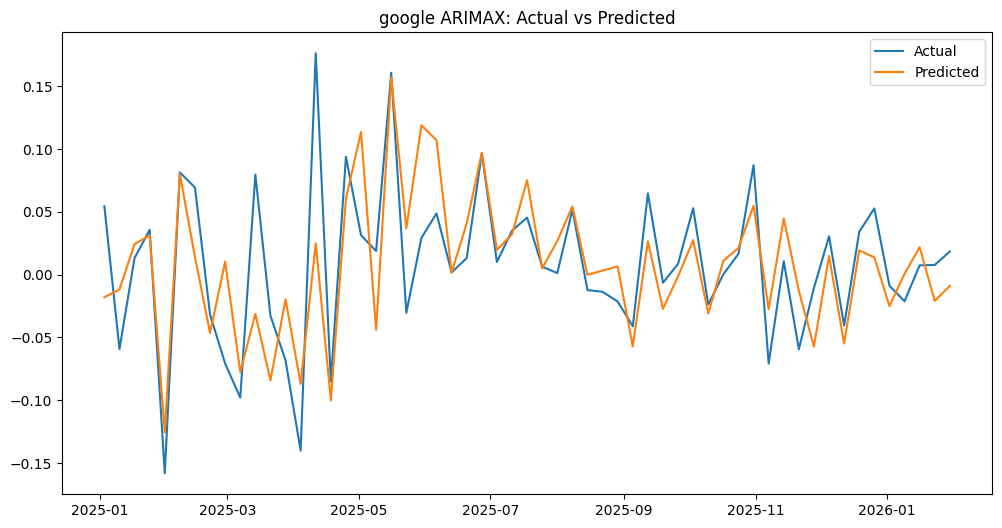

In [245]:
plt.figure(figsize=(12,6)) 
plt.plot(test['Return'], label='Actual') 
plt.plot(predictions, label='Predicted') 
plt.legend() 
plt.title("google ARIMAX: Actual vs Predicted") 
plt.show() 

Strategy Returns

In [246]:
signals = np.where(predictions > 0, "BUY", "SELL") 
 
strategy_returns = [] 
 
for i in range(len(test)): 
    if signals[i] == "BUY": 
        strategy_returns.append(test['Return'].iloc[i]) 
    else: 
        strategy_returns.append(-test['Return'].iloc[i]) 
 
strategy_returns = pd.Series(strategy_returns, index=test.index) 

Backtesting Visualization

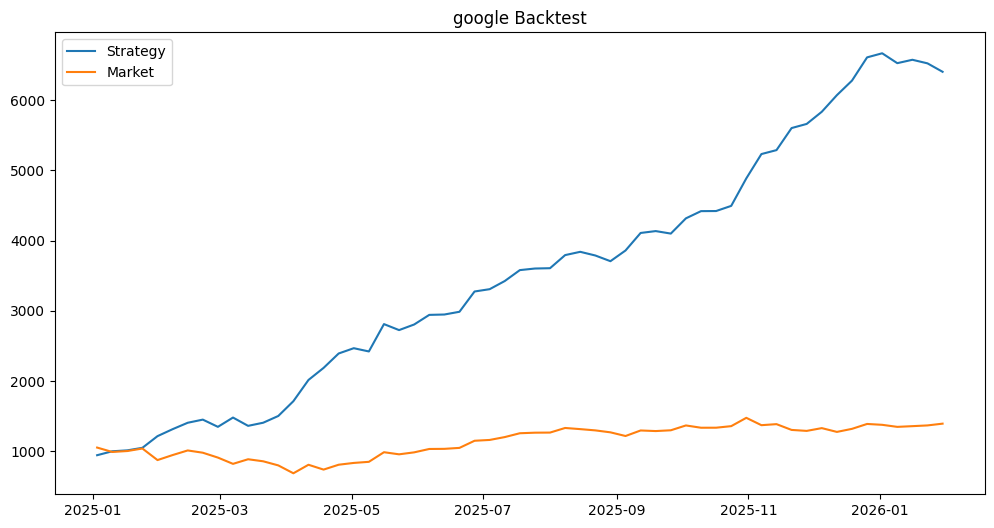

In [247]:
initial = 1000 
 
strategy_cum = (1 + strategy_returns).cumprod() * initial 
market_cum = (1 + test['Return']).cumprod() * initial 
 
plt.figure(figsize=(12,6)) 
plt.plot(strategy_cum, label="Strategy") 
plt.plot(market_cum, label="Market") 
plt.legend() 
plt.title("google Backtest") 
plt.show() 

MSFT STOCK PREDICTION

Data Loading and Preparation



In [248]:
df = pd.read_csv("../../data/MSFT.csv")

df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

df = df.sort_index()

print(df.head())

             Open   High    Low  Close   Adj Close       Volume
Date                                                           
2015-01-02  46.66  47.42  46.54   46.76       39.77  27,913,900
2015-01-05  46.37  46.73  46.25   46.33       39.40  39,673,900
2015-01-06  46.38  46.75  45.54   45.65       38.82  36,447,900
2015-01-07  45.98  46.46  45.49   46.23       39.32  29,114,100
2015-01-08  46.75  47.75  46.72   47.59       40.47  29,645,200


Convert to Weekly Data

The daily stock data was resampled into weekly frequency using Friday closing prices to reduce noise and capture more stable trends.

In [249]:
df = df.resample('W-FRI').last()

# Debug: check what columns actually exist after resample
print(df.columns.tolist())

# Strip whitespace from column names (common culprit)
df.columns = df.columns.str.strip()

df['Return'] = df['Close'].pct_change()
df = df.dropna()

['Open', 'High', 'Low', 'Close\xa0', 'Adj Close\xa0', 'Volume']


Feature Engineering 

In [250]:
# Lag features 
df['lag1'] = df['Return'].shift(1) 
df['lag2'] = df['Return'].shift(2) 
 
# Moving averages 
df['ma4'] = df['Return'].rolling(4).mean() 
df['ma8'] = df['Return'].rolling(8).mean() 
 
# Volatility 
df['volatility'] = df['Return'].rolling(4).std() 
 
df = df.dropna() 


Target

In [251]:
# 1-week ahead return 
df['target_1w'] = df['Return'].shift(-1) 
 
# 4-week ahead return 
df['target_4w'] = df['Return'].rolling(4).sum().shift(-4) 
 
df = df.dropna() 


Train/ Val/ Test Split

In [252]:
train = df[(df.index >= "2022-01-01") & (df.index < "2024-01-01")]
val = df[(df.index >= "2024-01-01") & (df.index < "2025-01-01")]
test_msft = df[df.index >= "2025-01-01"]

print("Train size:", len(train))
print("Val size:", len(val))
print("Test size:", len(test)) 


Train size: 104
Val size: 52
Test size: 57


Select Features

In [253]:
features = ['lag1', 'lag2', 'ma4', 'ma8', 'volatility'] 


Walk Forward ArimaX

In [254]:
def walk_forward_arimax(train, test, features): 
     
    history_y = list(train['Return']) 
    history_x = train[features].copy() 
     
    predictions = [] 
 
    for i in range(len(test)): 
         
        model = SARIMAX( 
            history_y, 
            exog=history_x, 
            order=(1,1,1), 
            enforce_stationarity=False, 
            enforce_invertibility=False 
        ) 
         
        model_fit = model.fit(disp=False) 
         
        exog_test = test[features].iloc[i:i+1] 
         
        yhat = model_fit.forecast(steps=1, exog=exog_test).iloc[0]
        predictions.append(yhat) 
         
        # update history 
        history_y.append(test['Return'].iloc[i]) 
        history_x = pd.concat([history_x, exog_test]) 
     
    return pd.Series(predictions, index=test.index)



Train Model & Predict

In [255]:
predictions = walk_forward_arimax(train, test, features) 
print(predictions.head())

Date
2025-01-03    0.000933
2025-01-10   -0.005459
2025-01-17    0.023208
2025-01-24    0.037411
2025-01-31   -0.061065
Freq: W-FRI, dtype: float64


In [256]:
pred_msft = walk_forward_arimax(train, test, features)

Evaluate Model

In [257]:
mae = mean_absolute_error(test['Return'], predictions) 
rmse = np.sqrt(mean_squared_error(test['Return'], predictions)) 
 
direction = np.mean(np.sign(predictions) == np.sign(test['Return'])) 
 
print("MAE:", mae) 
print("RMSE:", rmse) 
print("Directional Accuracy:", direction)

MAE: 0.03350445078093673
RMSE: 0.04514766729820658
Directional Accuracy: 0.8245614035087719


Plot Actual vs Predicted

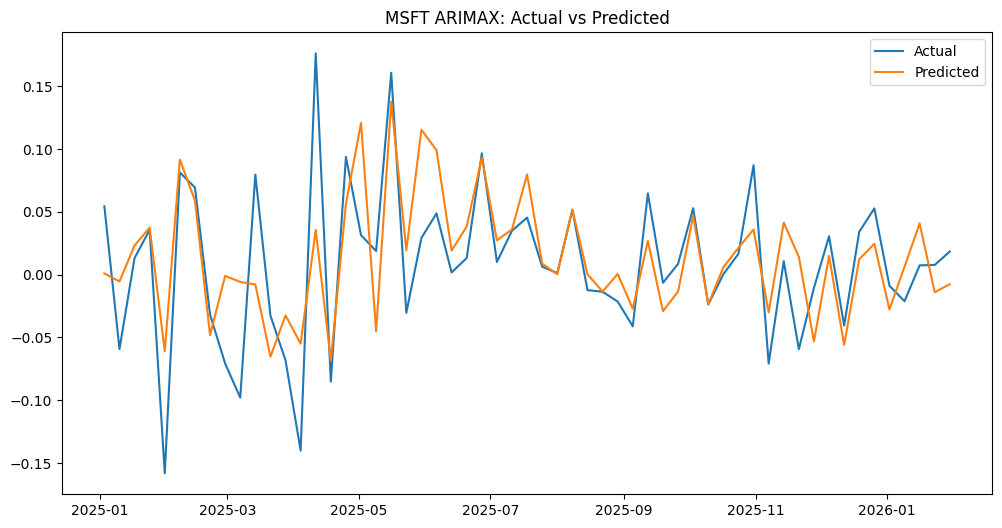

In [258]:
plt.figure(figsize=(12,6)) 
plt.plot(test['Return'], label='Actual') 
plt.plot(predictions, label='Predicted') 
plt.legend() 
plt.title("MSFT ARIMAX: Actual vs Predicted") 
plt.show() 

Strategy Returns

In [259]:
signals = np.where(predictions > 0, "BUY", "SELL") 
 
strategy_returns = [] 
 
for i in range(len(test)): 
    if signals[i] == "BUY": 
        strategy_returns.append(test['Return'].iloc[i]) 
    else: 
        strategy_returns.append(-test['Return'].iloc[i]) 
 
strategy_returns = pd.Series(strategy_returns, index=test.index) 

Visualization Backtesting

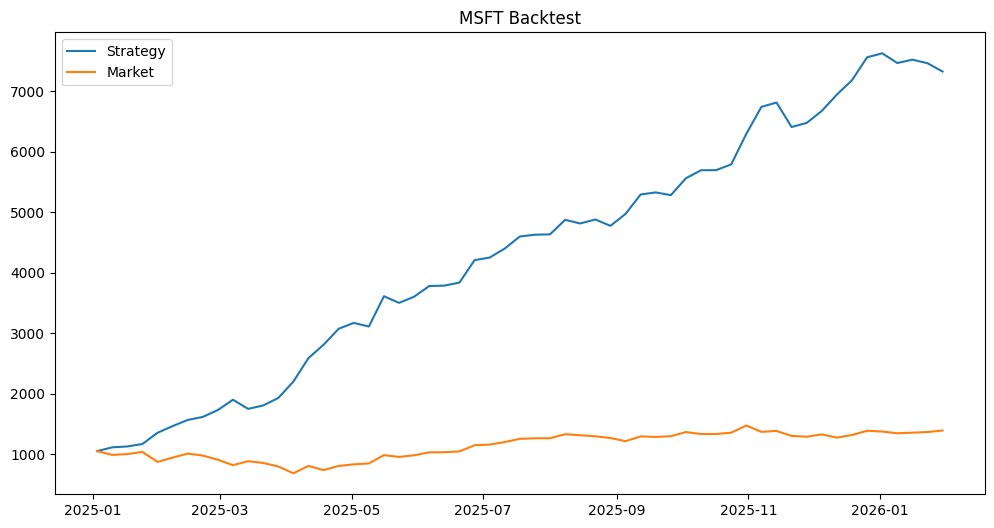

In [260]:
initial = 1000 
 
strategy_cum = (1 + strategy_returns).cumprod() * initial 
market_cum = (1 + test['Return']).cumprod() * initial 
 
plt.figure(figsize=(12,6)) 
plt.plot(strategy_cum, label="Strategy") 
plt.plot(market_cum, label="Market") 
plt.legend() 
plt.title("MSFT Backtest") 
plt.show() 

NVIDIA STOCK PREDICTION

Data Loading and Preparation

In [261]:
df = pd.read_csv("../../data/NVIDIA.csv")

df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

df = df.sort_index()

print(df.head())

            Open  High   Low  Close   Adj Close        Volume
Date                                                         
2015-01-02  0.50  0.51  0.50    0.50        0.48  113,680,000
2015-01-05  0.50  0.50  0.49    0.49        0.47  197,952,000
2015-01-06  0.50  0.50  0.48    0.48        0.46  197,764,000
2015-01-07  0.48  0.49  0.48    0.48        0.46  321,808,000
2015-01-08  0.48  0.50  0.48    0.50        0.48  283,780,000


Convert to Weekly Data

The daily stock data was resampled into weekly frequency using Friday closing prices to reduce noise and capture more stable trends.

In [262]:
df = df.resample('W-FRI').last()

# Debug: check what columns actually exist after resample
print(df.columns.tolist())

# Strip whitespace from column names (common culprit)
df.columns = df.columns.str.strip()

df['Return'] = df['Close'].pct_change()
df = df.dropna()

['Open', 'High', 'Low', 'Close\xa0', 'Adj Close\xa0', 'Volume']


Feature Engineering 

In [263]:
# Lag features 
df['lag1'] = df['Return'].shift(1) 
df['lag2'] = df['Return'].shift(2) 
 
# Moving averages 
df['ma4'] = df['Return'].rolling(4).mean() 
df['ma8'] = df['Return'].rolling(8).mean() 
 
# Volatility 
df['volatility'] = df['Return'].rolling(4).std() 
 
df = df.dropna() 
 


Target

In [264]:
# 1-week ahead return 
df['target_1w'] = df['Return'].shift(-1) 
 
# 4-week ahead return 
df['target_4w'] = df['Return'].rolling(4).sum().shift(-4) 
 
df = df.dropna() 


Train/ Val/ Test Split

In [265]:
train = df[(df.index >= "2022-01-01") & (df.index < "2024-01-01")]
val = df[(df.index >= "2024-01-01") & (df.index < "2025-01-01")]
test_nvda = df[df.index >= "2025-01-01"]

print("Train size:", len(train))
print("Val size:", len(val))
print("Test size:", len(test)) 


Train size: 104
Val size: 52
Test size: 57


Select Features

In [266]:
features = ['lag1', 'lag2', 'ma4', 'ma8', 'volatility'] 


Walk Forward ArimaX Function

In [267]:
def walk_forward_arimax(train, test, features): 
     
    history_y = list(train['Return']) 
    history_x = train[features].copy() 
     
    predictions = [] 
 
    for i in range(len(test)): 
         
        model = SARIMAX( 
            history_y, 
            exog=history_x, 
            order=(1,1,1), 
            enforce_stationarity=False, 
            enforce_invertibility=False 
        ) 
         
        model_fit = model.fit(disp=False) 
         
        exog_test = test[features].iloc[i:i+1] 
         
        yhat = model_fit.forecast(steps=1, exog=exog_test).iloc[0]
        predictions.append(yhat) 
         
        # update history 
        history_y.append(test['Return'].iloc[i]) 
        history_x = pd.concat([history_x, exog_test]) 
     
    return pd.Series(predictions, index=test.index)



Train Model & Prediction

In [268]:
predictions = walk_forward_arimax(train, test, features) 
print(predictions.head())

Date
2025-01-03   -0.006122
2025-01-10   -0.015479
2025-01-17    0.006977
2025-01-24    0.034146
2025-01-31   -0.086114
Freq: W-FRI, dtype: float64


In [269]:
pred_nvda = walk_forward_arimax(train, test, features)

Evaluate Model

In [270]:
mae = mean_absolute_error(test['Return'], predictions) 
rmse = np.sqrt(mean_squared_error(test['Return'], predictions)) 
 
direction = np.mean(np.sign(predictions) == np.sign(test['Return'])) 
 
print("MAE:", mae) 
print("RMSE:", rmse) 
print("Directional Accuracy:", direction) 


MAE: 0.03309974535782508
RMSE: 0.04463415341391052
Directional Accuracy: 0.7719298245614035


Plot Actual vs Predicted

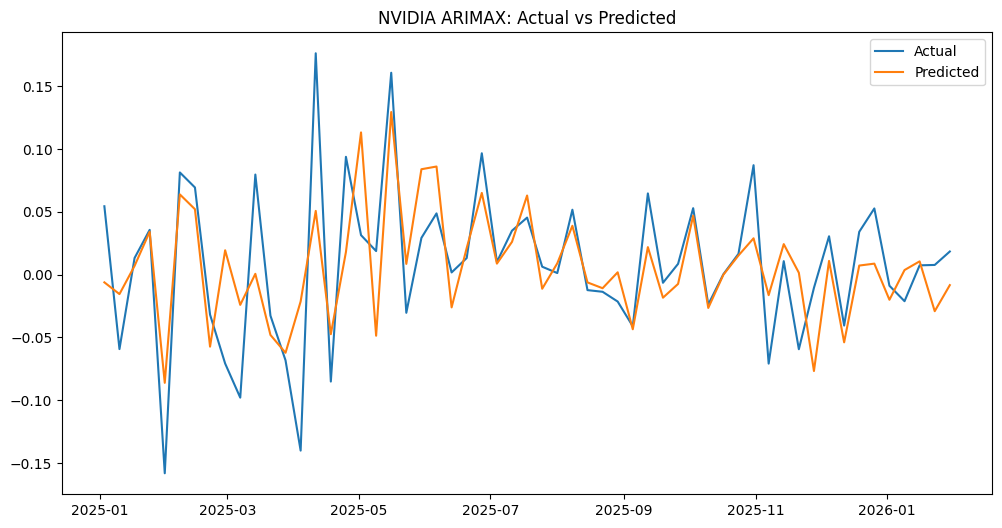

In [271]:
plt.figure(figsize=(12,6)) 
plt.plot(test['Return'], label='Actual') 
plt.plot(predictions, label='Predicted') 
plt.legend() 
plt.title("NVIDIA ARIMAX: Actual vs Predicted") 
plt.show() 

 

Strategy Returns

In [272]:
signals = np.where(predictions > 0, "BUY", "SELL") 
 
strategy_returns = [] 
 
for i in range(len(test)): 
    if signals[i] == "BUY": 
        strategy_returns.append(test['Return'].iloc[i]) 
    else: 
        strategy_returns.append(-test['Return'].iloc[i]) 
 
strategy_returns = pd.Series(strategy_returns, index=test.index) 

Plot Backtesting Results

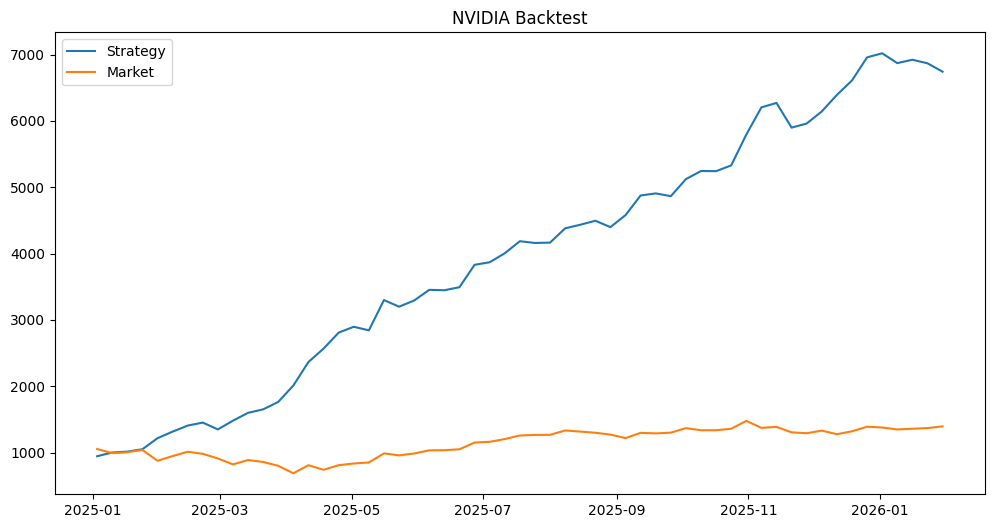

In [273]:
initial = 1000 
 
strategy_cum = (1 + strategy_returns).cumprod() * initial 
market_cum = (1 + test['Return']).cumprod() * initial 
 
plt.figure(figsize=(12,6)) 
plt.plot(strategy_cum, label="Strategy") 
plt.plot(market_cum, label="Market") 
plt.legend() 
plt.title("NVIDIA Backtest") 
plt.show() 

Combine All 5 stocks

Created one dataframe that contains predictions from all stocks 

In [ ]:
pred_aapl
pred_googl
pred_msft
pred_nvda
pred_amzn   


Date
2025-01-03   -0.006122
2025-01-10   -0.015479
2025-01-17    0.006977
2025-01-24    0.034146
2025-01-31   -0.086114
2025-02-07    0.063889
2025-02-14    0.052097
2025-02-21   -0.057305
2025-02-28    0.019421
2025-03-07   -0.024055
2025-03-14    0.000663
2025-03-21   -0.047997
2025-03-28   -0.062211
2025-04-04   -0.021356
2025-04-11    0.050759
2025-04-18   -0.047387
2025-04-25    0.018020
2025-05-02    0.113233
2025-05-09   -0.048617
2025-05-16    0.129448
2025-05-23    0.008566
2025-05-30    0.083924
2025-06-06    0.086082
2025-06-13   -0.026067
2025-06-20    0.021237
2025-06-27    0.065058
2025-07-04    0.008782
2025-07-11    0.026104
2025-07-18    0.063005
2025-07-25   -0.011222
2025-08-01    0.009048
2025-08-08    0.038903
2025-08-15   -0.006173
2025-08-22   -0.010792
2025-08-29    0.001875
2025-09-05   -0.043487
2025-09-12    0.021920
2025-09-19   -0.018335
2025-09-26   -0.007384
2025-10-03    0.046993
2025-10-10   -0.026501
2025-10-17   -0.000102
2025-10-24    0.015266
2025-1

Combining into One DataFrame

In [ ]:
predictions_all = pd.DataFrame({
    "AAPL": pred_aapl,
    "AMZN": pred_amzn,
    "GOOGL": pred_googl,
    "MSFT": pred_msft,
    "NVDA": pred_nvda
})

Verify

In [309]:
print(predictions_all.head())
print(predictions_all.shape)

                AAPL      AMZN     GOOGL      MSFT      NVDA
Date                                                        
2025-01-03 -0.006122 -0.006122 -0.006122 -0.006122 -0.006122
2025-01-10 -0.015479 -0.015479 -0.015479 -0.015479 -0.015479
2025-01-17  0.006977  0.006977  0.006977  0.006977  0.006977
2025-01-24  0.034146  0.034146  0.034146  0.034146  0.034146
2025-01-31 -0.086114 -0.086114 -0.086114 -0.086114 -0.086114
(57, 5)


Get Best Stock

In [310]:
top_stock = predictions_all.idxmax(axis=1)

print(top_stock.head())

Date
2025-01-03    AAPL
2025-01-10    AAPL
2025-01-17    AAPL
2025-01-24    AAPL
2025-01-31    AAPL
Freq: W-FRI, dtype: object


Get Actual Returns

In [282]:
actual_returns = pd.DataFrame({ 
   "AAPL": test_aapl['Return'], 
   "GOOGL": test_googl['Return'], 
   "MSFT": test_msft['Return'], 
   "NVDA": test_nvda['Return'] 
})

Strategy Returns

In [283]:
strategy_returns = []

for i in range(len(top_stock)):
    
    stock = top_stock.iloc[i]
    date = top_stock.index[i]
    
    ret = actual_returns.loc[date, stock]
    
    strategy_returns.append(ret)

strategy_returns = pd.Series(strategy_returns, index=top_stock.index)

Backtesting

In [284]:
initial = 1000

strategy_cum = (1 + strategy_returns).cumprod() * initial
market_cum = (1 + actual_returns.mean(axis=1)).cumprod() * initial

Plot Results

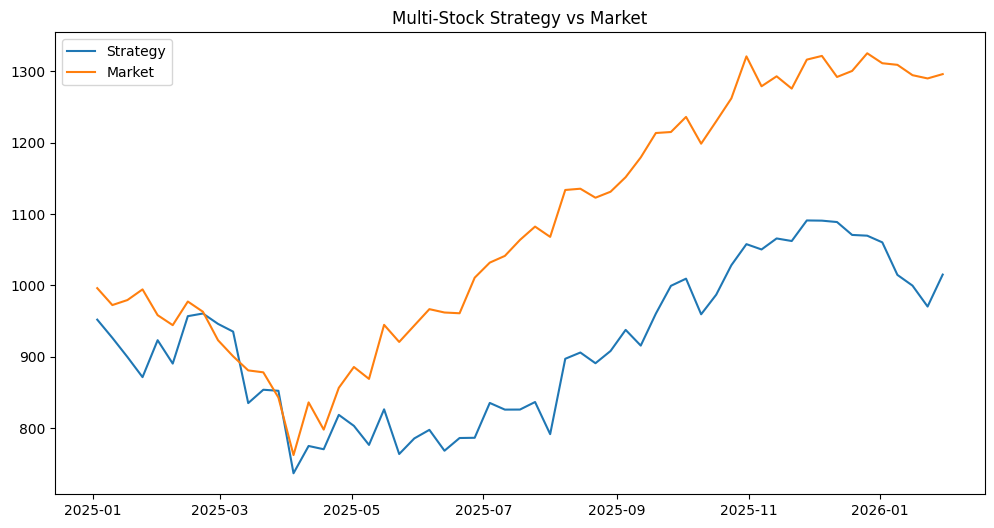

In [285]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(strategy_cum, label="Strategy")
plt.plot(market_cum, label="Market")

plt.legend()
plt.title("Multi-Stock Strategy vs Market")
plt.show()

Ranking Accuracy

In [286]:
correct = 0

for i in range(len(predictions_all)):
    
    date = predictions_all.index[i]
    
    pred_best = predictions_all.loc[date].idxmax()
    actual_best = actual_returns.loc[date].idxmax()
    
    if pred_best == actual_best:
        correct += 1

ranking_accuracy = correct / len(predictions_all)

print("Ranking Accuracy:", ranking_accuracy)

Ranking Accuracy: 0.2631578947368421


Combined predictions from multiple stocks into a unified framework, enabling dynamic ranking of assets and evaluation through backtesting and ranking accuracy metrics. 

EVALUATING ALL STOCKS TOGETHER

In [324]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd

Prediction & Actual values Dictionary

In [303]:
predictions_dict = {
    "AAPL": pred_aapl,
    "GOOGL": pred_googl,
    "MSFT": pred_msft,
    "NVDA": pred_nvda,
    "AMZN": pred_amzn
}

actual_dict = {
    "AAPL": test_aapl['Return'],
    "GOOGL": test_googl['Return'],
    "MSFT": test_msft['Return'],
    "NVDA": test_nvda['Return'],
    "AMZN": test_amzn['Return']
}


Claculate Metrics

In [301]:
results = []

for stock in predictions_dict:
    
    pred = predictions_dict[stock]
    actual = actual_dict[stock]
    
    # Align indices (VERY IMPORTANT)
    pred, actual = pred.align(actual, join='inner')
    
    mae = mean_absolute_error(actual, pred)
    rmse = np.sqrt(mean_squared_error(actual, pred))
    
    directional_accuracy = np.mean(
        (np.sign(pred) == np.sign(actual)).astype(int)
    )
    
    results.append({
        "Stock": stock,
        "MAE": round(mae, 5),
        "RMSE": round(rmse, 5),
        "Directional Accuracy": round(directional_accuracy, 3)
    })


Convert to DataFrame

In [302]:
results_df = pd.DataFrame(results)

print(results_df)

   Stock      MAE     RMSE  Directional Accuracy
0   AAPL  0.04487  0.05667                 0.526
1  GOOGL  0.03992  0.05366                 0.614
2   MSFT  0.02994  0.03944                 0.667
3   NVDA  0.03310  0.04463                 0.772
4   AMZN  0.03942  0.04993                 0.579


Visualization of model performance across stocks shows that predictive accuracy varies significantly, with more stable stocks achieving higher directional accuracy while highly volatile stocks exhibit larger prediction errors. 

ARIMA Model Performance Across Stocks

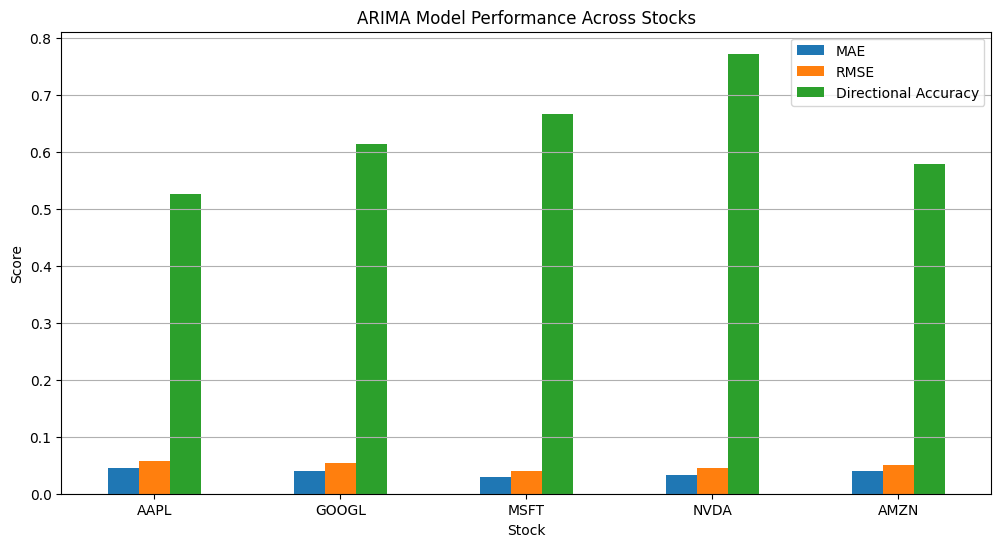

In [312]:
import matplotlib.pyplot as plt 
 
# Set index 
results_df.set_index('Stock', inplace=True) 
 
# Plot 
results_df.plot(kind='bar', figsize=(12,6)) 
 
plt.title("ARIMA Model Performance Across Stocks") 
plt.ylabel("Score") 
plt.xticks(rotation=0) 
plt.grid(axis='y') 
 
plt.legend() 
plt.show() 


Separate Graph

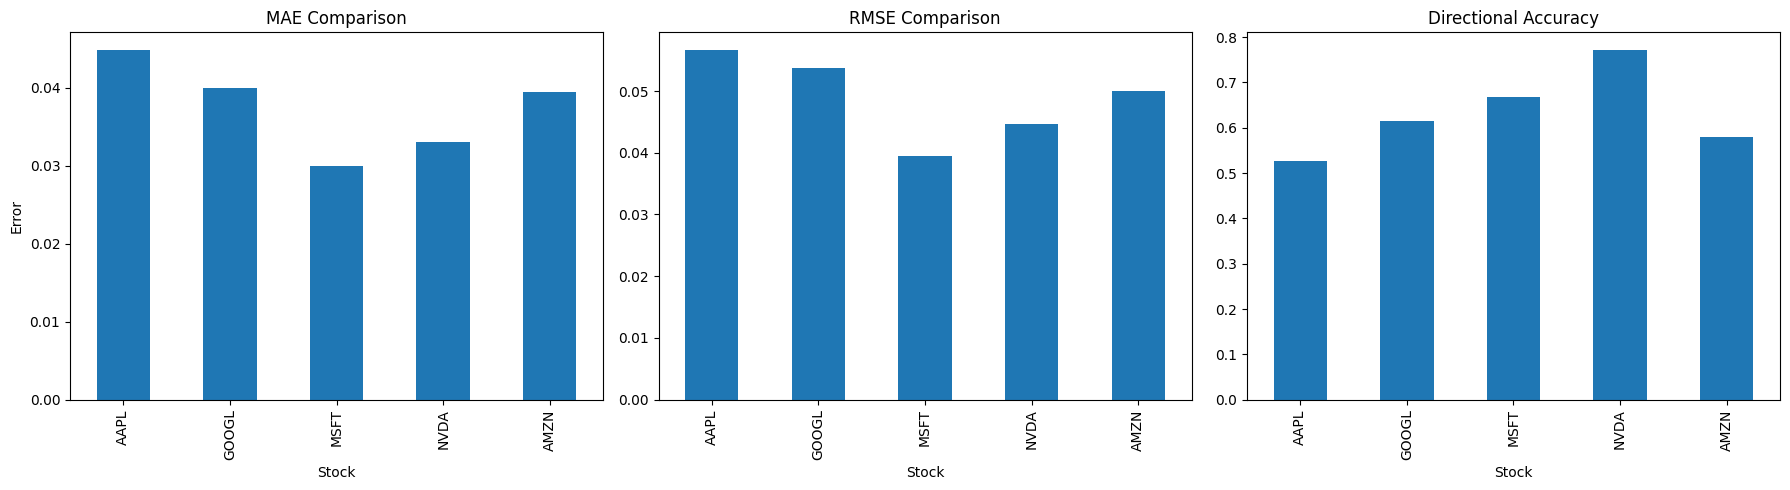

In [313]:
fig, axes = plt.subplots(1, 3, figsize=(18,5)) 
 
# MAE 
results_df['MAE'].plot(kind='bar', ax=axes[0]) 
axes[0].set_title("MAE Comparison") 
axes[0].set_ylabel("Error") 
 
# RMSE 
results_df['RMSE'].plot(kind='bar', ax=axes[1]) 
axes[1].set_title("RMSE Comparison") 
 
# Directional Accuracy 
results_df['Directional Accuracy'].plot(kind='bar', ax=axes[2]) 
axes[2].set_title("Directional Accuracy") 
 
plt.tight_layout() 
plt.show() 


Highlight Best Stock

In [314]:
best_stock = results_df['Directional Accuracy'].idxmax() 
 
print("Best Performing Stock:", best_stock) 


Best Performing Stock: NVDA


Performance Trend Across Stocks

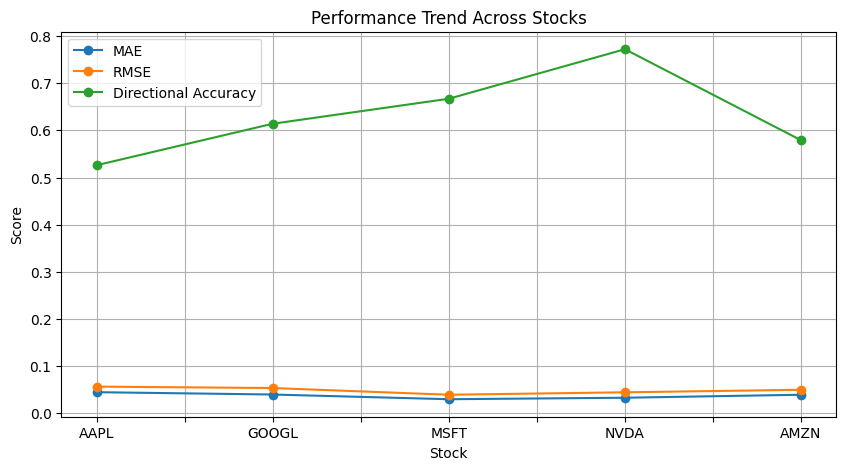

In [316]:
results_df.plot(marker='o', figsize=(10,5)) 
 
plt.title("Performance Trend Across Stocks") 
plt.ylabel("Score") 
plt.grid() 
 
plt.show() 


Ranking System For Best Sock Per Week

In [318]:
predictions_all   # DataFrame (all stock predictions)
actual_returns    # DataFrame (all actual returns)

,AAPL,GOOGL,MSFT,NVDA
Date,,,,
2025-01-03,-0.047850,-0.005032,-0.016677,0.054449
2025-01-10,-0.026750,0.001304,-0.010393,-0.059251
2025-01-17,-0.029006,0.020621,0.024060,0.013244
2025-01-24,-0.031307,0.021480,0.035033,0.035655
2025-01-31,0.059341,0.019030,-0.065306,-0.158112
2025-02-07,-0.035466,-0.091560,-0.012793,0.081369
2025-02-14,0.074551,-0.000594,-0.003221,0.069393
2025-02-21,0.003884,-0.030071,-0.000539,-0.031833
2025-02-28,-0.015109,-0.052210,-0.027486,-0.070743


Rank Stocks Every Week

In [288]:
ranking = predictions_all.rank(axis=1, ascending=False)

Pick Best Stock Each Week

In [289]:
top_stock = predictions_all.idxmax(axis=1)

print(top_stock.head())

Date
2025-01-03    AAPL
2025-01-10    AAPL
2025-01-17    AAPL
2025-01-24    AAPL
2025-01-31    AAPL
Freq: W-FRI, dtype: object


Add to DataFrame

In [290]:
predictions_all['Top_Stock'] = top_stock

Show Full Ranking Table 

In [291]:
ranking['Top_Stock'] = top_stock
print(ranking.head())

            AAPL  AMZN  GOOGL  MSFT  NVDA Top_Stock
Date                                               
2025-01-03   3.0   3.0    3.0   3.0   3.0      AAPL
2025-01-10   3.0   3.0    3.0   3.0   3.0      AAPL
2025-01-17   3.0   3.0    3.0   3.0   3.0      AAPL
2025-01-24   3.0   3.0    3.0   3.0   3.0      AAPL
2025-01-31   3.0   3.0    3.0   3.0   3.0      AAPL


Apply Strategy

In [292]:
strategy_returns = []

for i in range(len(top_stock)):
    
    stock = top_stock.iloc[i]
    date = top_stock.index[i]
    
    ret = actual_returns.loc[date, stock]
    
    strategy_returns.append(ret)

strategy_returns = pd.Series(strategy_returns, index=top_stock.index)

Weekly Portfolio Growth

In [293]:
initial = 1000

strategy_cum = (1 + strategy_returns).cumprod() * initial

Weekly Stock Selection Strategy

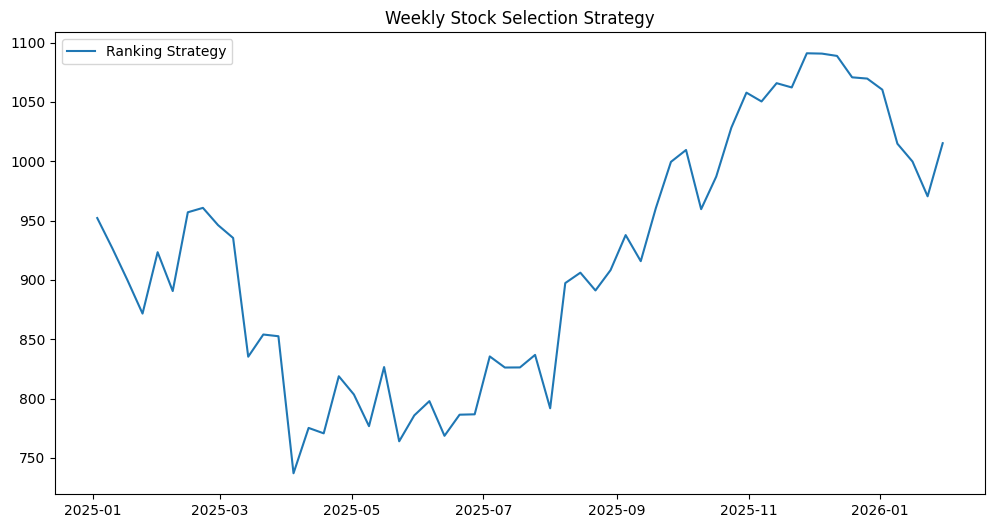

In [294]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(strategy_cum, label="Ranking Strategy")
plt.title("Weekly Stock Selection Strategy")
plt.legend()
plt.show()

Implemented a weekly ranking system by selecting the stock with the highest predicted return, enabling dynamic portfolio allocation and evaluation through backtesting. 

Cumulative Ranking Accuracy

In [319]:
correct = []
dates = []

for date in predictions_all.index:
    
    pred_best = predictions_all.loc[date].idxmax()
    actual_best = actual_returns.loc[date].idxmax()
    
    if pred_best == actual_best:
        correct.append(1)
    else:
        correct.append(0)
    
    dates.append(date)

ranking_df = pd.DataFrame({
    "Date": dates,
    "Correct": correct
})

ranking_df.set_index("Date", inplace=True)

# Overall accuracy
ranking_accuracy = ranking_df['Correct'].mean()

print("Overall Ranking Accuracy:", ranking_accuracy)

Overall Ranking Accuracy: 0.2631578947368421


Cumulative Ranking Accuracy Over Time

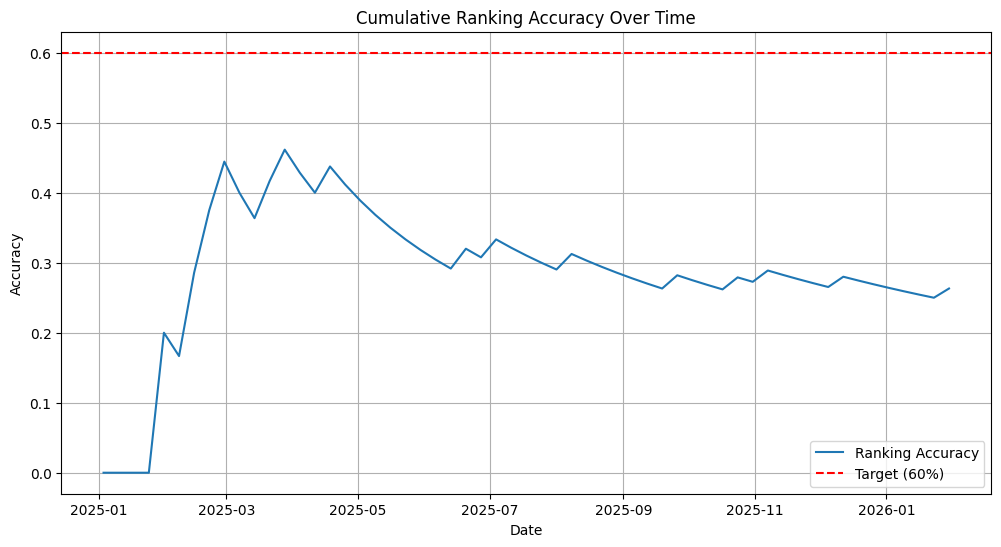

In [320]:
ranking_df['Cumulative Accuracy'] = ranking_df['Correct'].expanding().mean()

import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(ranking_df.index, ranking_df['Cumulative Accuracy'], label="Ranking Accuracy")

plt.axhline(y=0.6, color='r', linestyle='--', label="Target (60%)")

plt.title("Cumulative Ranking Accuracy Over Time")
plt.xlabel("Date")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()

plt.show()

Daily/Weekly Correct Prediction

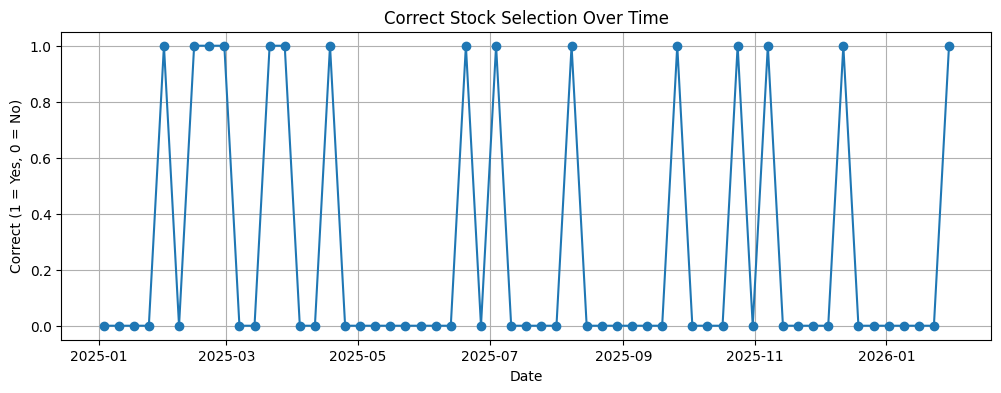

In [321]:
plt.figure(figsize=(12,4))

plt.plot(ranking_df.index, ranking_df['Correct'], marker='o')

plt.title("Correct Stock Selection Over Time")
plt.xlabel("Date")
plt.ylabel("Correct (1 = Yes, 0 = No)")
plt.grid()

plt.show()

Accuracy Distribution

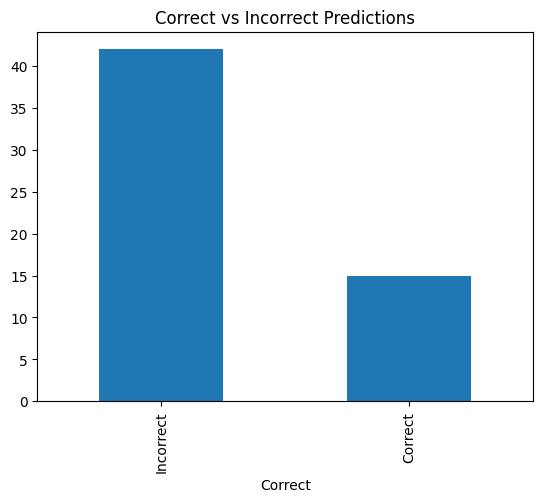

In [322]:
ranking_df['Correct'].value_counts().plot(kind='bar')

plt.title("Correct vs Incorrect Predictions")
plt.xticks([0,1], ["Incorrect", "Correct"])
plt.show()

The cumulative ranking accuracy plot demonstrates the model’s ability to correctly identify the best-performing stock over time, providing a direct measure of decision-making effectiveness relative to the target benchmark.